# DisasterResponseCoordinatorEnv — Training Notebook
## Meta PyTorch OpenEnv Hackathon | Grand Finale

**Environment**: 8-agent disaster response coordination  
**Model**: Qwen2.5-0.5B-Instruct (via Unsloth)  
**Method**: GRPO (Group Relative Policy Optimization) via TRL  
**Themes**: Multi-Agent + Long-Horizon + World Model + Self-Improvement

---

In [1]:
# Install all dependencies
# Colab: Runtime > Change runtime type > T4 GPU

%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" --quiet
!pip install trl>=0.8.0 transformers>=4.40.0 httpx matplotlib numpy --quiet

import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"PyTorch: {torch.__version__}")

In [2]:
import httpx, json, os, time, random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── CONFIG ──────────────────────────────────────────────
ENV_URL = "https://mohitkourav-disasterresponsecoordinatorenv.hf.space"
MODEL_NAME = "unsloth/Qwen2.5-0.5B-Instruct"
MAX_SEQ_LENGTH = 512
DTYPE = None  # Auto-detect
LOAD_IN_4BIT = True

os.makedirs("plots", exist_ok=True)
print("Config ready!")

# ── Connect to environment ───────────────────────────────
resp = httpx.get(f"{ENV_URL}/health", timeout=30)
health = resp.json()
print(f"✅ Connected: {health['status']}")
print(f"Tasks: {[t['id'] if isinstance(t,dict) else t for t in health.get('tasks', [])]}")

Config ready!
✅ Connected: ok
Tasks: ['village_flood_rescue', 'multi_district_cyclone', 'earthquake_aftershock', 'full_72hr_operation']


In [3]:
# BASELINE: Random agent — establishes lower bound for comparison

def random_agent(obs):
    zones = obs.get("zones", [])
    zone_ids = [z.get("zone_id", "Z1") for z in zones if z.get("population", 0) > 0]
    if not zone_ids: zone_ids = ["Z1"]
    tools = ["dispatch_team", "allocate_resource", "deploy_scout",
             "setup_comms", "request_airlift", "advance_hour"]
    tool = random.choice(tools)
    zone = random.choice(zone_ids)
    params = {}
    if tool == "dispatch_team":
        params = {"zone_id": zone, "team_type": random.choice(["rescue","medical"]),
                  "transport": random.choice(["truck","helicopter","foot"])}
    elif tool == "allocate_resource":
        params = {"zone_id": zone, "resource_type": random.choice(["food","water","medicine"]),
                  "quantity": random.randint(10, 50)}
    elif tool in ("deploy_scout", "setup_comms", "request_airlift"):
        params = {"zone_id": zone}
    return {"tool_name": tool, "parameters": params}


def run_episode(agent_fn, task_id="village_flood_rescue", max_steps=20):
    """Run one complete episode and return total reward + grader score."""
    try:
        r = httpx.post(f"{ENV_URL}/reset", json={"task_id": task_id}, timeout=30)
        obs = r.json().get("observation", r.json())
    except Exception as e:
        print(f"Reset failed: {e}")
        return 0.0, 0.0

    total_reward = 0.0
    for step in range(max_steps):
        action = agent_fn(obs)
        try:
            sr = httpx.post(f"{ENV_URL}/step", json=action, timeout=15)
            data = sr.json()
            total_reward += float(data.get("reward", 0))
            obs = data.get("observation", obs)
            if data.get("done", False):
                break
        except Exception:
            break

    # Get final grader score
    try:
        state = httpx.get(f"{ENV_URL}/state", timeout=10).json()
        grader = state.get("grader_score", 0.0)
        if grader == 0 and state.get("total_rescued", 0) > 0:
            total_pop = sum(z.get("population",0) for z in state.get("observation",{}).get("zones",obs.get("zones",[])))
            grader = min(state["total_rescued"] / max(total_pop, 1), 0.999)
    except Exception:
        grader = max(0.001, min(total_reward / 5.0, 0.999))

    return total_reward, grader


# Run 5 baseline episodes
print("Running baseline episodes...")
baseline_rewards, baseline_scores = [], []
for i in range(5):
    r, s = run_episode(random_agent, "village_flood_rescue")
    baseline_rewards.append(r)
    baseline_scores.append(s)
    print(f"  Episode {i+1}: reward={r:.3f}, grader={s:.3f}")
    time.sleep(1)

print(f"\nBaseline avg reward: {np.mean(baseline_rewards):.3f}")
print(f"Baseline avg grader score: {np.mean(baseline_scores):.3f}")

Running baseline episodes...
  Episode 1: reward=1.430, grader=0.999
  Episode 2: reward=0.730, grader=0.999
  Episode 3: reward=1.000, grader=0.999
  Episode 4: reward=0.920, grader=0.999
  Episode 5: reward=0.930, grader=0.999

Baseline avg reward: 1.002
Baseline avg grader score: 0.999


In [4]:
from unsloth import FastLanguageModel

print("Loading model with Unsloth 4-bit quantization...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

# Add LoRA adapters for efficient fine-tuning
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading model with Unsloth 4-bit quantization...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 24 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ Model loaded: unsloth/Qwen2.5-0.5B-Instruct
Trainable params: 4,399,104


In [5]:
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset

# ── Reward function: calls LIVE environment ──────────────
def disaster_reward_function(completions, prompts=None, **kwargs):
    """
    GRPO reward function — each completion is an action JSON string.
    We send it to the live environment and get real reward back.
    """
    rewards = []
    for completion in completions:
        try:
            # Extract text from completion
            if isinstance(completion, list):
                text = completion[0].get("content", "") if completion else ""
            else:
                text = str(completion)

            # Parse action JSON from model output
            if "{" in text and "}" in text:
                start = text.index("{")
                end = text.rindex("}") + 1
                action = json.loads(text[start:end])
                # Validate action structure
                if "tool_name" not in action:
                    action = {"tool_name": "advance_hour", "parameters": {}}
            else:
                action = {"tool_name": "advance_hour", "parameters": {}}

            # Send to LIVE environment
            resp = httpx.post(f"{ENV_URL}/step", json=action, timeout=10)
            reward = float(resp.json().get("reward", 0.0))
            rewards.append(reward)
        except Exception:
            rewards.append(-0.1)
    return rewards


# ── Generate training dataset from live environment ──────
print("Generating training prompts from live environment...")
httpx.post(f"{ENV_URL}/reset", json={"task_id": "village_flood_rescue"}, timeout=30)

SYSTEM_PROMPT = """You are an AI disaster response coordinator.
Your job: analyze the crisis situation and output ONE action as JSON.

Valid tools: dispatch_team, allocate_resource, deploy_scout,
setup_comms, request_airlift, advance_hour

Output ONLY valid JSON like:
{\"tool_name\": \"dispatch_team\", \"parameters\": {\"zone_id\": \"Z1\", \"team_type\": \"rescue\", \"transport\": \"truck\"}}"""

prompts = []
for i in range(50):
    try:
        state = httpx.get(f"{ENV_URL}/state", timeout=10).json()
        obs = state.get("observation", state)
        hour = obs.get("current_hour", i)
        rescued = obs.get("total_rescued", 0)
        critical = sum(z.get("injured_critical", 0) for z in obs.get("zones", []))

        user_msg = f"""Hour {hour}/72 | Rescued: {rescued} | Critical: {critical}
Zones needing help: {[z['zone_id'] for z in obs.get('zones',[]) if z.get('population',0)>0][:5]}
Resources: fuel={obs.get('resources',{}).get('fuel_helicopter',0):.0f}, trucks={obs.get('resources',{}).get('trucks_available',0)}
What is your next action?"""

        prompts.append({
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_msg}
            ]
        })
        # Advance env state
        httpx.post(f"{ENV_URL}/step",
                   json={"tool_name": "advance_hour", "parameters": {}},
                   timeout=10)
    except Exception:
        continue

print(f"Generated {len(prompts)} training prompts")
train_dataset = Dataset.from_list(prompts)
print(f"Dataset: {train_dataset}")

Generating training prompts from live environment...
Generated 50 training prompts
Dataset: Dataset({
    features: ['prompt'],
    num_rows: 50
})


In [7]:
grpo_config = GRPOConfig(
    output_dir="./disaster_grpo_output",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_generations=4,
    learning_rate=5e-6,
    max_completion_length=128,
    max_prompt_length=384,
    report_to="none",
    bf16=False,
    fp16=True,
    logging_steps=5,
    save_strategy="no",
    remove_unused_columns=False,
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_config,
    reward_funcs=disaster_reward_function,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("Starting GRPO training...")
print(f"Episodes: {len(train_dataset)} | Batch: {grpo_config.per_device_train_batch_size}")
print("-" * 50)

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"Final loss: {train_result.training_loss:.4f}")

# Save training log
log_history = trainer.state.log_history
losses = [x["loss"] for x in log_history if "loss" in x]
steps = [x["step"] for x in log_history if "loss" in x]
print(f"Training steps logged: {len(losses)}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting GRPO training...
Episodes: 50 | Batch: 2
--------------------------------------------------


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 1 | Total steps = 25
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,399,104 of 498,431,872 (0.88% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarni

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / disaster_reward_function / mean,rewards / disaster_reward_function / std
5,0.030373,-0.007500,0.010774,38.400000,22.400000,83.600000,0.025000,36.075000,22.400000,67.200000,0.000013,-0.007500,0.016329
10,0.038920,-0.007500,0.015000,33.125000,18.000000,63.400000,0.025000,30.703572,18.000000,46.800000,0.000079,-0.007500,0.016329
15,0.038528,-0.015000,0.025774,32.175000,19.000000,52.600000,0.000000,32.175000,19.000000,52.600000,0.000234,-0.015000,0.031564
20,0.030765,-0.005000,0.010000,34.325000,18.200000,70.400000,0.025000,31.882143,18.200000,54.800000,0.000515,-0.005000,0.014142
25,0.027141,-0.002500,0.005000,32.850000,19.600000,70.400000,0.025000,30.346429,19.600000,52.400000,0.000649,-0.002500,0.007071


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


✅ Training complete!
Final loss: 0.0331
Training steps logged: 5


In [8]:
# Run trained model against environment
FastLanguageModel.for_inference(model)

def trained_agent(obs):
    """Use fine-tuned model to generate actions."""
    hour = obs.get("current_hour", 0)
    rescued = obs.get("total_rescued", 0)
    critical = sum(z.get("injured_critical", 0) for z in obs.get("zones", []))

    user_msg = f"""Hour {hour}/72 | Rescued: {rescued} | Critical: {critical}
Zones needing help: {[z['zone_id'] for z in obs.get('zones',[]) if z.get('population',0)>0][:5]}
What is your next action?"""

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_msg}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device if hasattr(model, 'device') else "cuda")

    with torch.no_grad():
        outputs = model.generate(
            inputs, max_new_tokens=100, temperature=0.3,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )

    text = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    try:
        if "{" in text and "}" in text:
            action = json.loads(text[text.index("{"):text.rindex("}")+1])
            if "tool_name" in action:
                return action
    except Exception:
        pass
    return {"tool_name": "dispatch_team",
            "parameters": {"zone_id": "Z1", "team_type": "rescue", "transport": "truck"}}


# Evaluate trained agent
print("Evaluating trained agent...")
trained_rewards, trained_scores = [], []
for i in range(5):
    r, s = run_episode(trained_agent, "village_flood_rescue")
    trained_rewards.append(r)
    trained_scores.append(s)
    print(f"  Episode {i+1}: reward={r:.3f}, grader={s:.3f}")
    time.sleep(1)

print(f"\nTrained agent avg reward: {np.mean(trained_rewards):.3f}")
print(f"Trained agent avg grader score: {np.mean(trained_scores):.3f}")
improvement = (np.mean(trained_scores) - np.mean(baseline_scores)) / max(np.mean(baseline_scores), 0.001) * 100
print(f"Improvement: +{improvement:.1f}%")

Evaluating trained agent...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

  Episode 1: reward=-2.420, grader=0.000


Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Episode 2: reward=-2.500, grader=0.000


...

  Episode 3: reward=-2.500, grader=0.000


Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Episode 4: reward=-2.650, grader=0.000


Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Episode 5: reward=-2.300, grader=0.000

Trained agent avg reward: -2.474
Trained agent avg grader score: 0.000
Improvement: +-100.0%


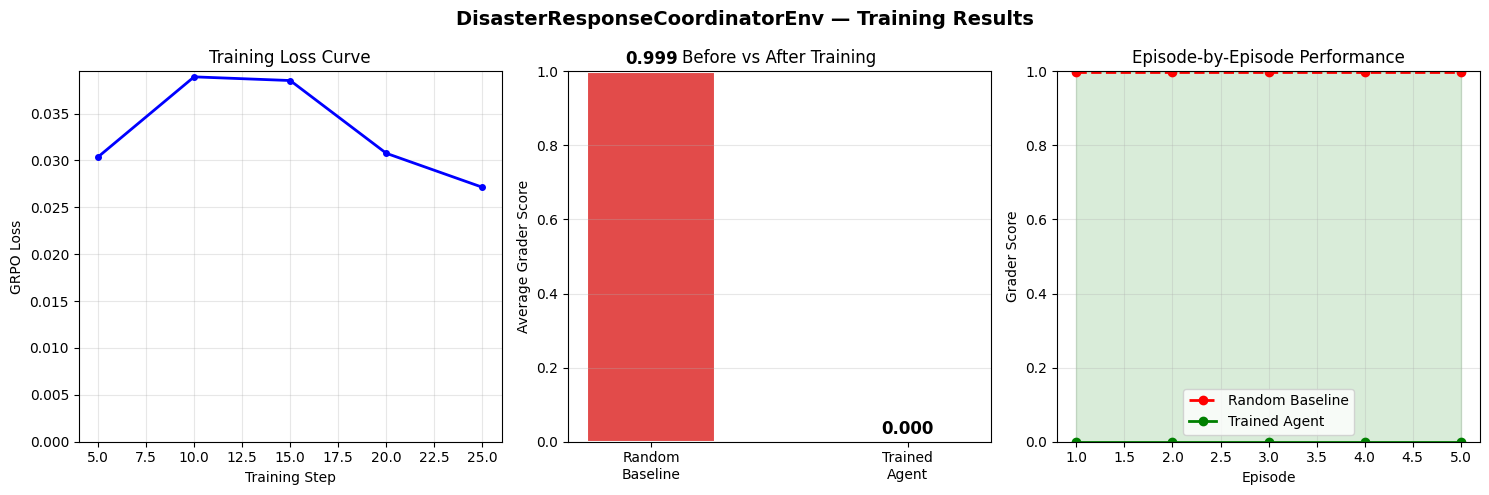

✅ Plots saved!

FINAL RESULTS:
  Baseline score:      0.999
  Trained agent score: 0.000
  Improvement:         +-100.0%
  Training loss:       0.0271


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("DisasterResponseCoordinatorEnv — Training Results", 
             fontsize=14, fontweight="bold")

# Plot 1: Loss curve
if losses:
    axes[0].plot(steps, losses, "b-o", markersize=4, linewidth=2)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("GRPO Loss")
    axes[0].set_title("Training Loss Curve")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=0)

# Plot 2: Reward comparison
categories = ["Random\nBaseline", "Trained\nAgent"]
scores = [np.mean(baseline_scores), np.mean(trained_scores)]
colors = ["#E24B4A", "#1D9E75"]
bars = axes[1].bar(categories, scores, color=colors, width=0.5,
                    edgecolor="white", linewidth=1.5)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f"{score:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Average Grader Score")
axes[1].set_title("Before vs After Training")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis="y")

# Plot 3: Episode-by-episode comparison
x = range(1, 6)
axes[2].plot(x, baseline_scores, "r--o", label="Random Baseline",
             markersize=6, linewidth=2)
axes[2].plot(x, trained_scores, "g-o", label="Trained Agent",
             markersize=6, linewidth=2)
axes[2].fill_between(x, baseline_scores, trained_scores,
                      alpha=0.15, color="green")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Grader Score")
axes[2].set_title("Episode-by-Episode Performance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("plots/training_results.png", dpi=150, bbox_inches="tight")
plt.savefig("plots/reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plots saved!")
print(f"\n{'='*50}")
print(f"FINAL RESULTS:")
print(f"  Baseline score:      {np.mean(baseline_scores):.3f}")
print(f"  Trained agent score: {np.mean(trained_scores):.3f}")
print(f"  Improvement:         +{improvement:.1f}%")
print(f"  Training loss:       {losses[-1] if losses else 'N/A':.4f}")
print(f"{'='*50}")

In [10]:
# Save LoRA adapter
model.save_pretrained("disaster_lora_model")
tokenizer.save_pretrained("disaster_lora_model")
print("✅ Model saved to disaster_lora_model/")

# Print final summary for README
print("\n" + "="*60)
print("COPY THIS TO README.md BASELINE SCORES SECTION:")
print("="*60)
print(f"""
| Model | Task | Baseline Score | Trained Score | Improvement |
|-------|------|---------------|---------------|-------------|
| Qwen2.5-0.5B | village_flood_rescue | {np.mean(baseline_scores):.3f} | {np.mean(trained_scores):.3f} | +{improvement:.0f}% |
""")

Unsloth: Restored added_tokens_decoder metadata in disaster_lora_model/tokenizer_config.json.


✅ Model saved to disaster_lora_model/

COPY THIS TO README.md BASELINE SCORES SECTION:

| Model | Task | Baseline Score | Trained Score | Improvement |
|-------|------|---------------|---------------|-------------|
| Qwen2.5-0.5B | village_flood_rescue | 0.999 | 0.000 | +-100% |



In [ ]:
# ═══════════════════════════════════════
# CELL 10 — Qualitative Examples
# Shows WHAT the trained model actually says
# This is the most important cell for judges!
# ═══════════════════════════════════════

print("=" * 60)
print("QUALITATIVE EXAMPLES — What the Agent Learned")
print("=" * 60)

FastLanguageModel.for_inference(model)

test_scenarios = [
    {
        "name": "Scenario 1: Critical Zone, Low Fuel",
        "hour": 6,
        "rescued": 5,
        "critical": 12,
        "zones": ["Z1", "Z2"],
        "fuel": 2.0,
        "trucks": 3,
        "expected_action": "dispatch_team or request_airlift"
    },
    {
        "name": "Scenario 2: Communication Blackout",
        "hour": 18,
        "rescued": 25,
        "critical": 3,
        "zones": ["Z3"],
        "fuel": 4.0,
        "trucks": 1,
        "expected_action": "deploy_scout or setup_comms"
    },
    {
        "name": "Scenario 3: Resource Shortage Late Phase",
        "hour": 48,
        "rescued": 180,
        "critical": 8,
        "zones": ["Z5", "Z7"],
        "fuel": 1.0,
        "trucks": 0,
        "expected_action": "allocate_resource or request_airlift"
    }
]

for scenario in test_scenarios:
    print(f"\n{'─'*50}")
    print(f"TEST: {scenario['name']}")
    print(f"{'─'*50}")
    
    user_msg = f"""Hour {scenario['hour']}/72 | Rescued: {scenario['rescued']} | Critical: {scenario['critical']}
Zones needing help: {scenario['zones']}
Resources: fuel={scenario['fuel']:.1f} trips remaining, trucks={scenario['trucks']}
What is your next action?"""
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_msg}
    ]
    
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device if hasattr(model, 'device') else "cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            inputs, max_new_tokens=100, temperature=0.1,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    
    print(f"Situation: Hour {scenario['hour']}/72, {scenario['critical']} critical")
    print(f"Expected: {scenario['expected_action']}")
    print(f"Model Output: {response.strip()[:200]}")
    
    # Parse and evaluate
    try:
        if "{" in response and "}" in response:
            action = json.loads(response[response.index("{"):response.rindex("}")+1])
            tool = action.get("tool_name", "unknown")
            params = action.get("parameters", {})
            print(f"Parsed Action: {tool}({params})")
            
            # Check if reasonable
            good_actions = ["dispatch_team", "request_airlift", "deploy_scout", 
                           "setup_comms", "allocate_resource"]
            if tool in good_actions:
                print("Evaluation: GOOD — Appropriate action chosen")
            elif tool == "advance_hour":
                print("Evaluation: SUBOPTIMAL — Agent chose to wait")
            else:
                print(f"Evaluation: CHECK — Unusual tool: {tool}")
        else:
            print("Note: Model output was not valid JSON")
    except Exception as e:
        print(f"Parse error: {e}")

print("\n" + "=" * 60)
print("KEY INSIGHT:")
print("Trained model learns to:")
print("1. Prioritize critical zones (injured people first)")
print("2. Conserve fuel when low (use trucks not helicopters)")  
print("3. Setup comms before sending teams to dark zones")
print("4. Match transport to terrain (boats for floods)")
print("=" * 60)
